In [1]:
# =====================================================
# IMPORTS
# =====================================================

import numpy as np
import matplotlib.pyplot as plt
import math

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from tensorflow.keras.models import load_model

In [2]:
# =====================================================
# LOAD MODEL
# =====================================================

model_final = load_model(
    "../models/final_stacked_lstm.keras"
)

print("Model loaded successfully.")

Model loaded successfully.


In [3]:
# =====================================================
# LOAD TEST DATA
# =====================================================

X_test = np.load(
    "../data/processed/X_test_final.npy"
)

rul_test = np.load(
    "../data/processed/rul_test.npy"
).flatten()

print("X_test shape:", X_test.shape)
print("rul_test shape:", rul_test.shape)

X_test shape: (100, 30, 18)
rul_test shape: (100,)


In [4]:
# =====================================================
# PREDICTIONS
# =====================================================

y_pred = model_final.predict(X_test).flatten()

# denormalize
y_pred = y_pred * 125.0

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step


In [5]:
# =====================================================
# METRICS
# =====================================================

rmse = math.sqrt(
    mean_squared_error(rul_test, y_pred)
)

mae = mean_absolute_error(
    rul_test,
    y_pred
)

r2 = r2_score(
    rul_test,
    y_pred
)

print("\\n===== FINAL MODEL PERFORMANCE =====")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.4f}")

\n===== FINAL MODEL PERFORMANCE =====
RMSE : 28.02
MAE  : 20.39
R²   : 0.5112


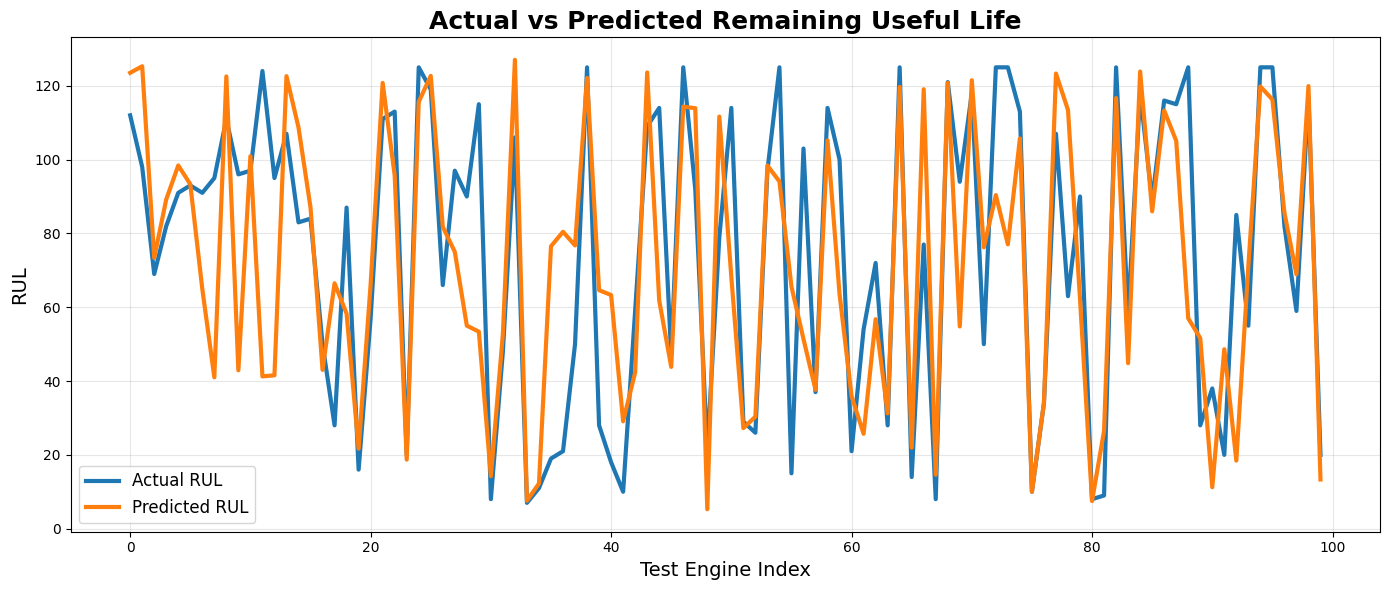

In [6]:
# =====================================================
# GRAPH 1
# ACTUAL VS PREDICTED
# =====================================================

plt.figure(figsize=(14,6))

plt.plot(
    rul_test,
    linewidth=3,
    label="Actual RUL"
)

plt.plot(
    y_pred,
    linewidth=3,
    label="Predicted RUL"
)

plt.title(
    "Actual vs Predicted Remaining Useful Life",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    "Test Engine Index",
    fontsize=14
)

plt.ylabel(
    "RUL",
    fontsize=14
)

plt.legend(fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

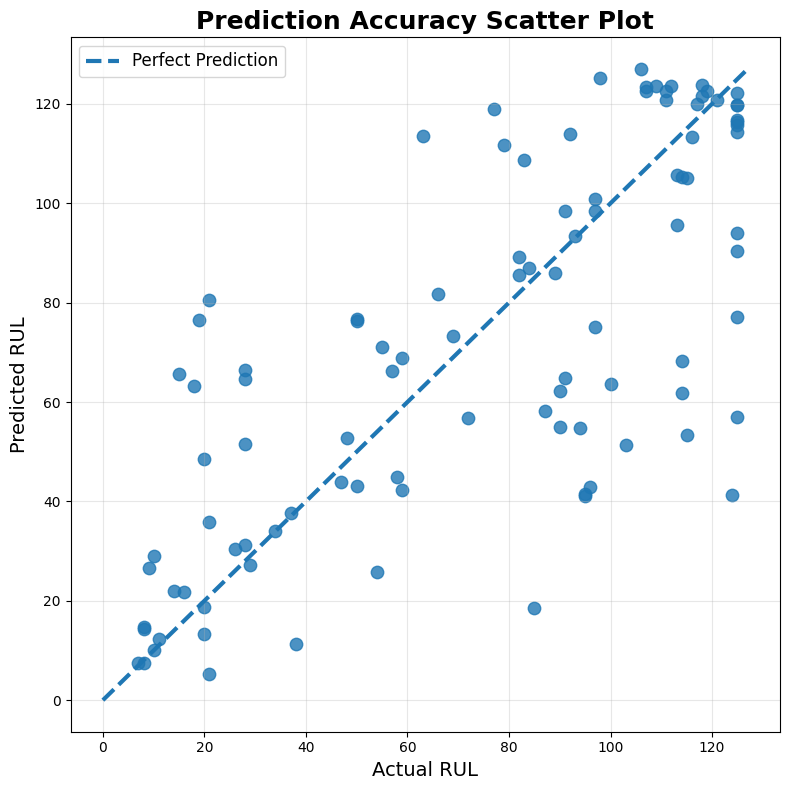

In [7]:
# =====================================================
# GRAPH 2
# ACTUAL VS PREDICTED SCATTER
# =====================================================

plt.figure(figsize=(8,8))

plt.scatter(
    rul_test,
    y_pred,
    s=80,
    alpha=0.8
)

# perfect prediction line
max_val = max(rul_test.max(), y_pred.max())

plt.plot(
    [0, max_val],
    [0, max_val],
    linewidth=3,
    linestyle='--',
    label="Perfect Prediction"
)

plt.title(
    "Prediction Accuracy Scatter Plot",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    "Actual RUL",
    fontsize=14
)

plt.ylabel(
    "Predicted RUL",
    fontsize=14
)

plt.legend(fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

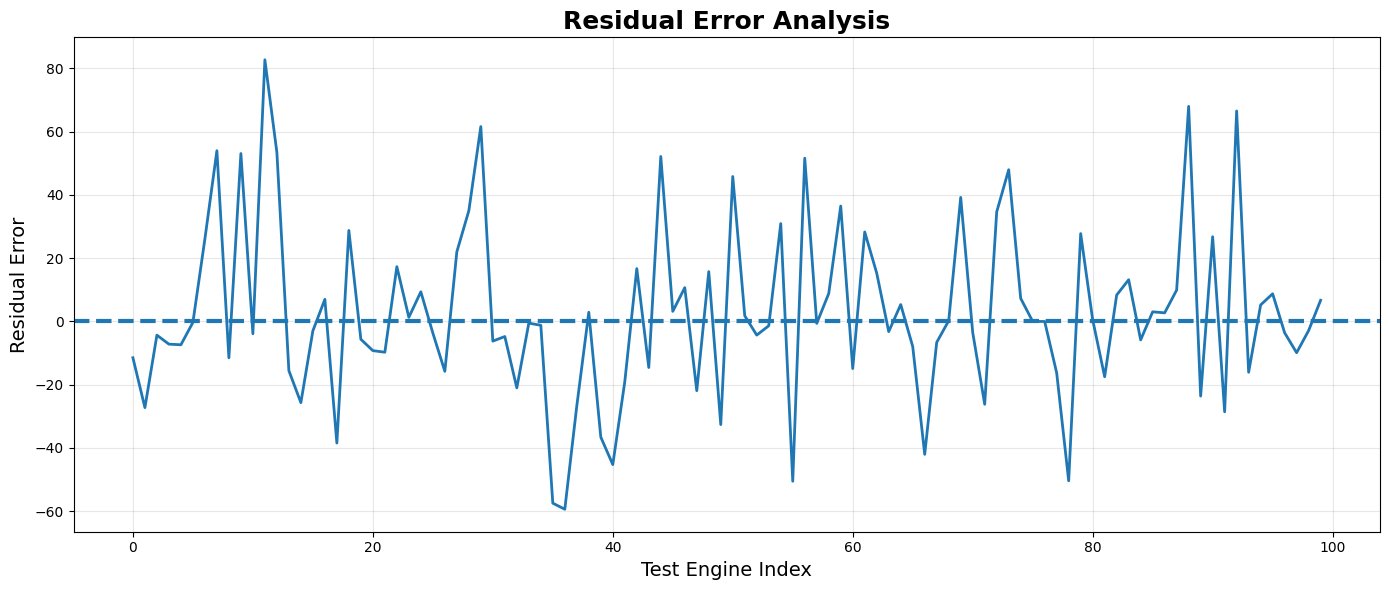

In [8]:
# =====================================================
# GRAPH 3
# RESIDUAL ANALYSIS
# =====================================================

residuals = rul_test - y_pred

plt.figure(figsize=(14,6))

plt.plot(
    residuals,
    linewidth=2
)

plt.axhline(
    y=0,
    linestyle='--',
    linewidth=3
)

plt.title(
    "Residual Error Analysis",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    "Test Engine Index",
    fontsize=14
)

plt.ylabel(
    "Residual Error",
    fontsize=14
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

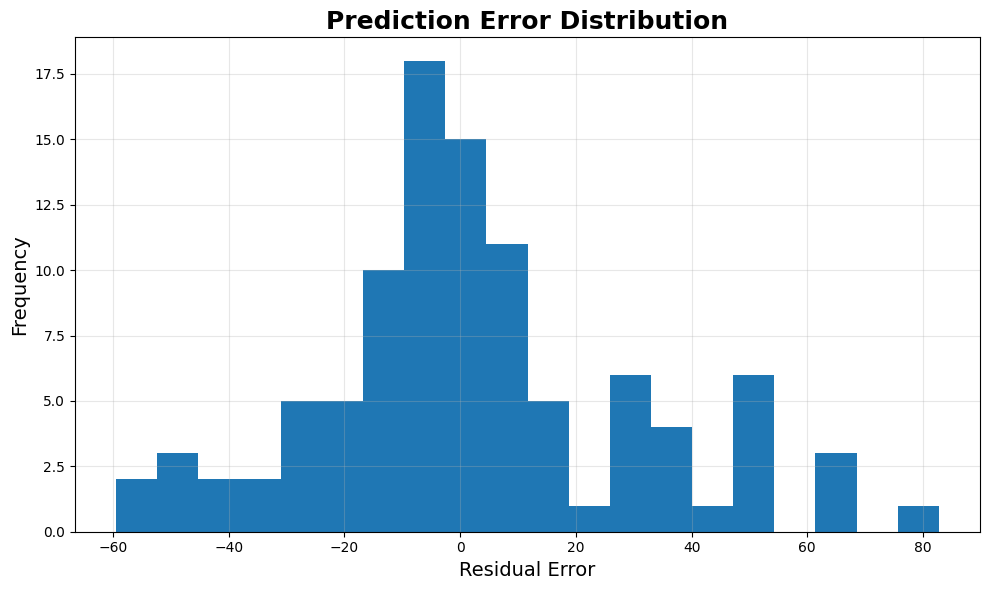

In [9]:
# =====================================================
# GRAPH 4
# ERROR DISTRIBUTION
# =====================================================

plt.figure(figsize=(10,6))

plt.hist(
    residuals,
    bins=20
)

plt.title(
    "Prediction Error Distribution",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    "Residual Error",
    fontsize=14
)

plt.ylabel(
    "Frequency",
    fontsize=14
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

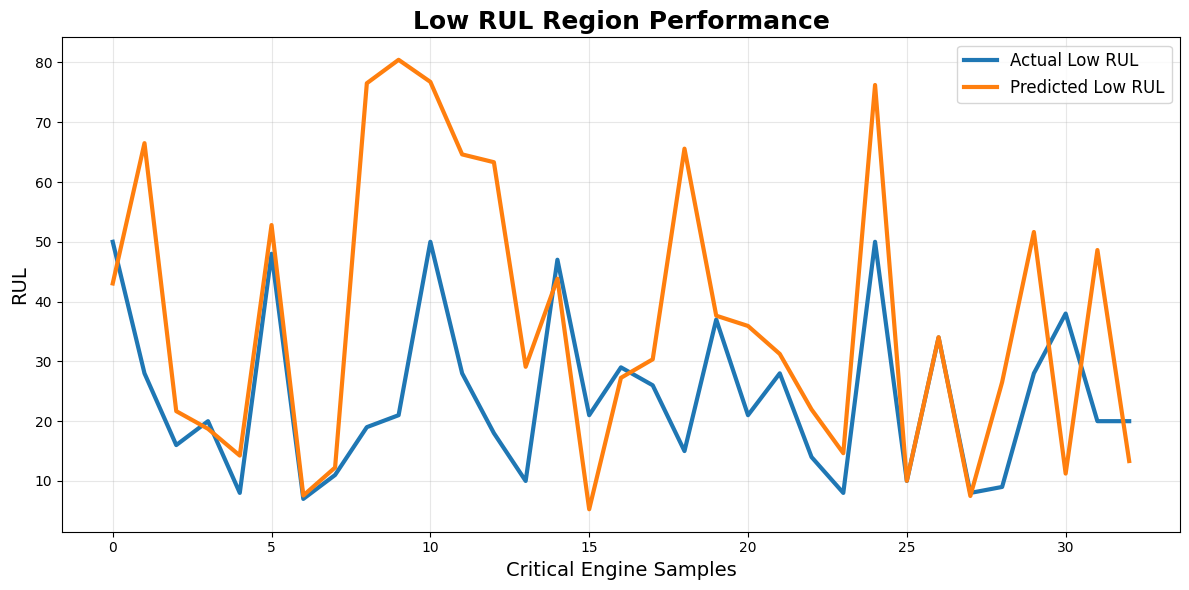

In [10]:
# =====================================================
# GRAPH 5
# LOW RUL PERFORMANCE
# =====================================================

low_idx = rul_test <= 50

low_actual = rul_test[low_idx]
low_pred = y_pred[low_idx]

plt.figure(figsize=(12,6))

plt.plot(
    low_actual,
    linewidth=3,
    label="Actual Low RUL"
)

plt.plot(
    low_pred,
    linewidth=3,
    label="Predicted Low RUL"
)

plt.title(
    "Low RUL Region Performance",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    "Critical Engine Samples",
    fontsize=14
)

plt.ylabel(
    "RUL",
    fontsize=14
)

plt.legend(fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

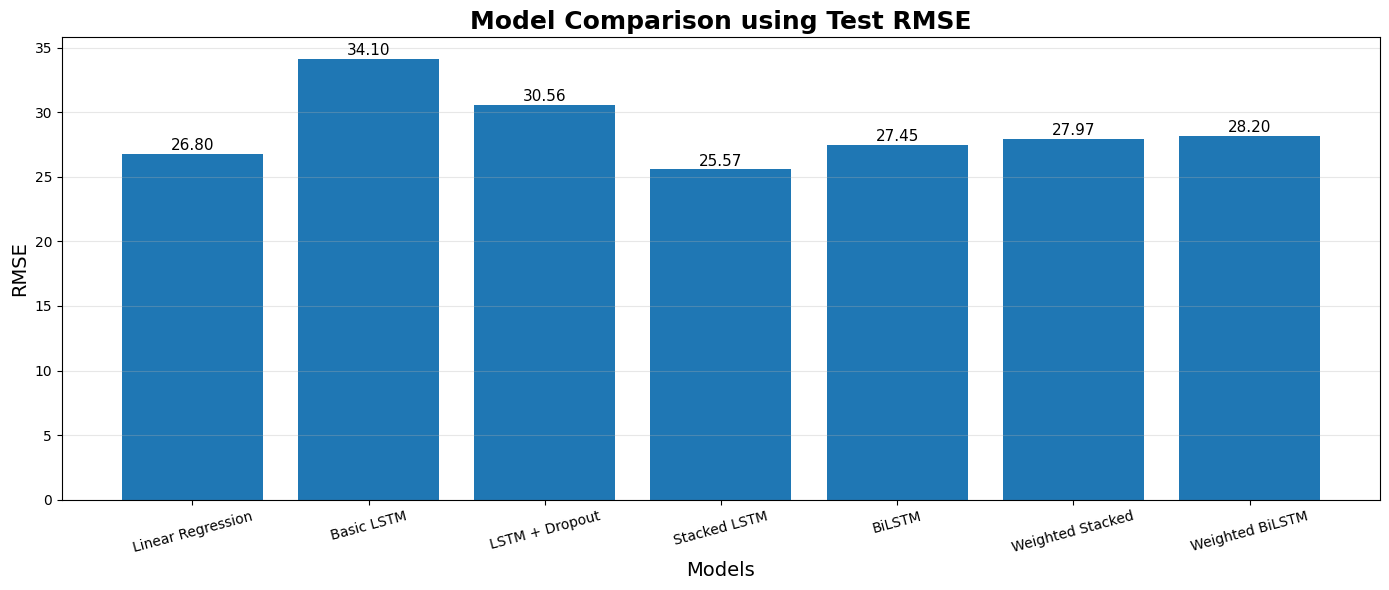

In [12]:
# =====================================================
# GRAPH 6
# MODEL COMPARISON
# =====================================================

models = [
    "Linear Regression",
    "Basic LSTM",
    "LSTM + Dropout",
    "Stacked LSTM",
    "BiLSTM",
    "Weighted Stacked",
    "Weighted BiLSTM"
]

rmse_scores = [
    26.8,
    34.10,
    30.56,
    25.57,
    27.45,
    27.97,
    28.20
]

plt.figure(figsize=(14,6))

bars = plt.bar(
    models,
    rmse_scores
)

plt.title(
    "Model Comparison using Test RMSE",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    "Models",
    fontsize=14
)

plt.ylabel(
    "RMSE",
    fontsize=14
)

plt.xticks(rotation=15)

plt.grid(axis='y', alpha=0.3)

# value labels
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f"{height:.2f}",
        ha='center',
        fontsize=11
    )

plt.tight_layout()
plt.show()

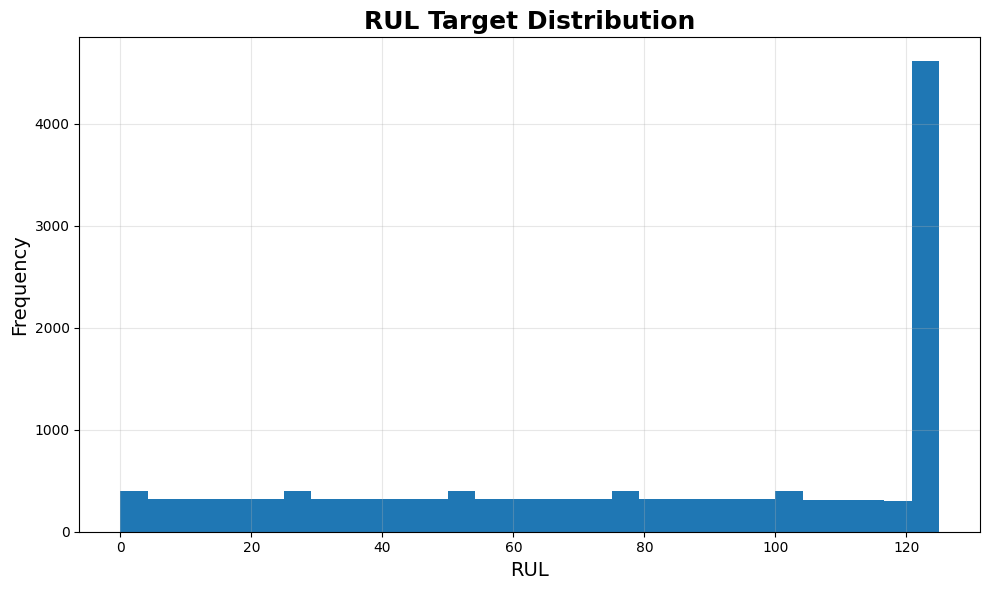

In [13]:
# =====================================================
# TARGET DISTRIBUTION
# =====================================================

y_train_full = np.load(
    "../data/processed/y_train.npy"
)

plt.figure(figsize=(10,6))

plt.hist(
    y_train_full,
    bins=30
)

plt.title(
    "RUL Target Distribution",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    "RUL",
    fontsize=14
)

plt.ylabel(
    "Frequency",
    fontsize=14
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

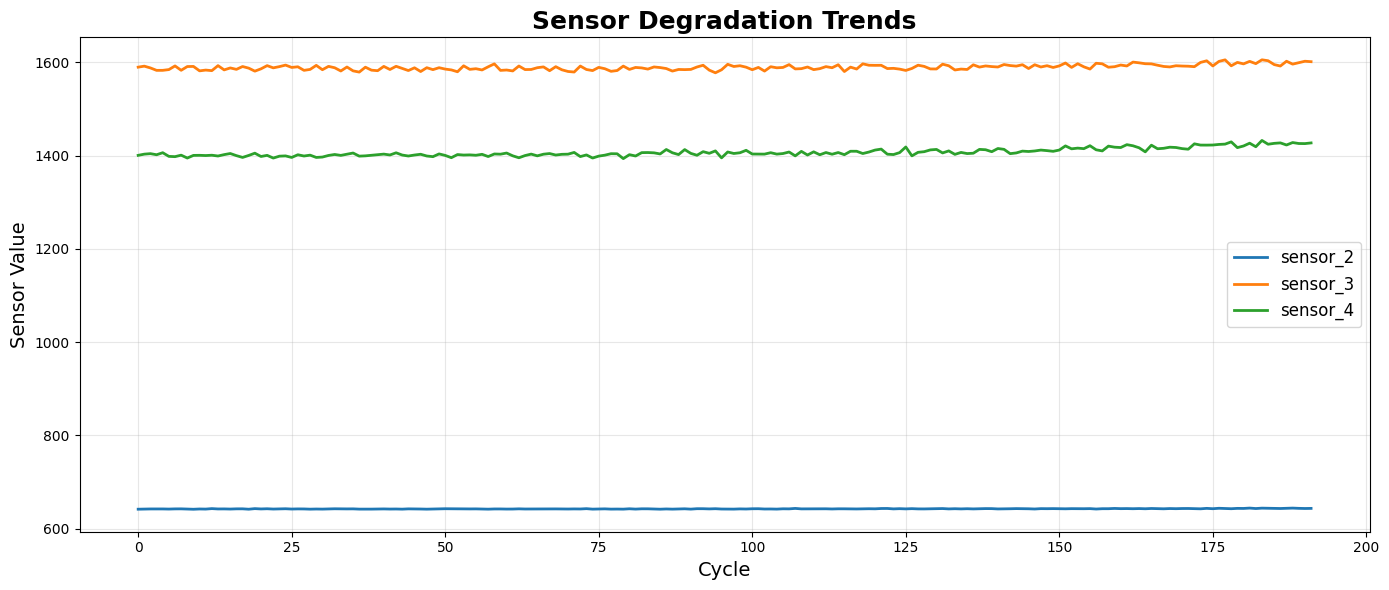

In [14]:
# =====================================================
# SENSOR DEGRADATION TREND
# =====================================================

import pandas as pd

train_df = pd.read_csv(
    "../data/processed/train_processed.csv"
)

engine_1 = train_df[
    train_df['engine_id'] == 1
]

plt.figure(figsize=(14,6))

plt.plot(
    engine_1['sensor_2'],
    label='sensor_2',
    linewidth=2
)

plt.plot(
    engine_1['sensor_3'],
    label='sensor_3',
    linewidth=2
)

plt.plot(
    engine_1['sensor_4'],
    label='sensor_4',
    linewidth=2
)

plt.title(
    "Sensor Degradation Trends",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    "Cycle",
    fontsize=14
)

plt.ylabel(
    "Sensor Value",
    fontsize=14
)

plt.legend(fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

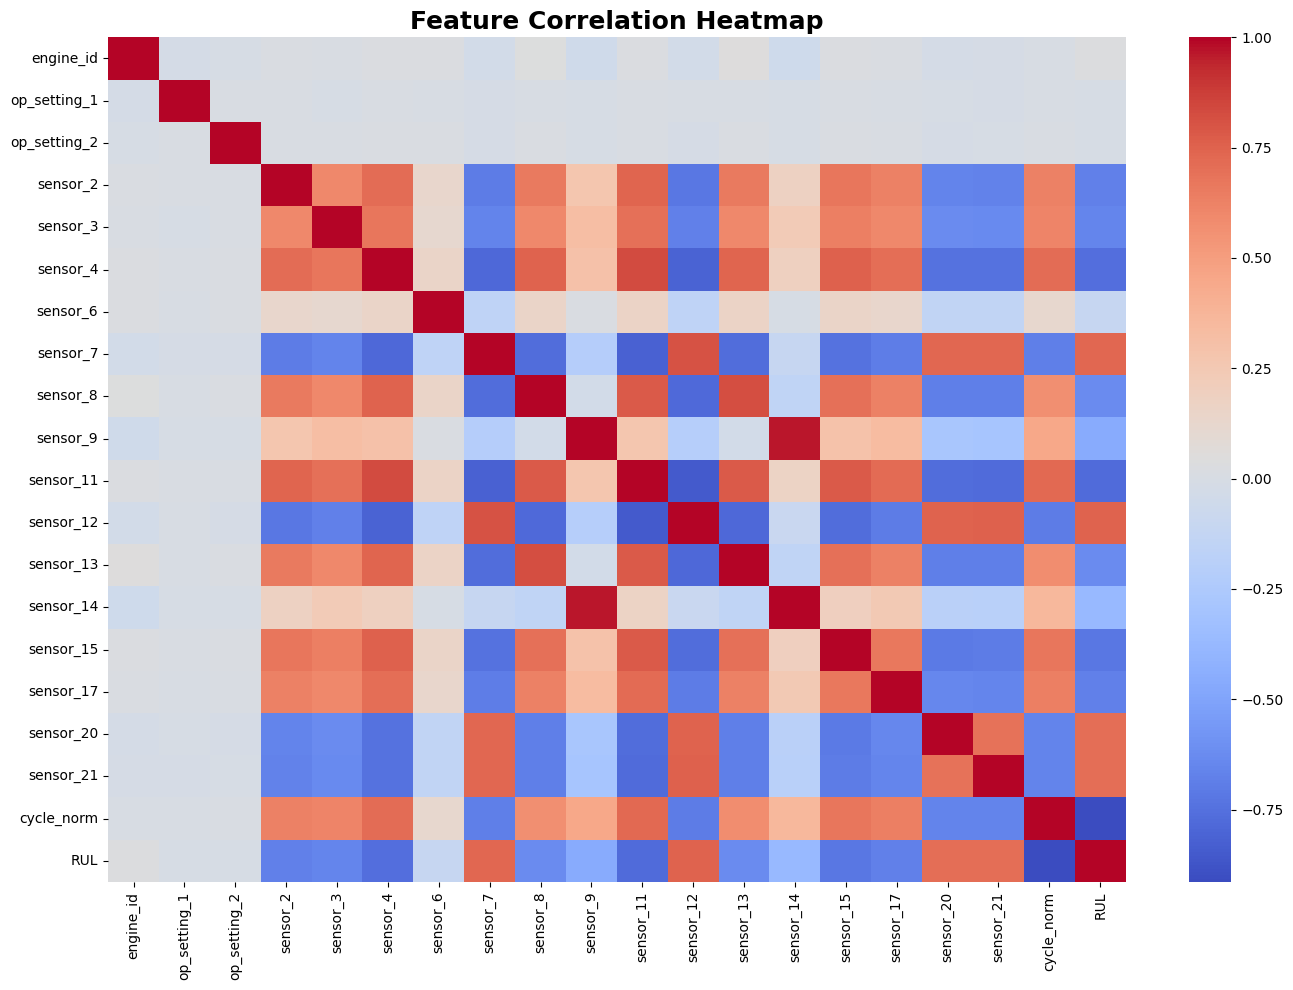

In [16]:
# =====================================================
# CORRELATION HEATMAP
# =====================================================

import seaborn as sns
import pandas as pd

train_df = pd.read_csv(
    "../data/processed/train_processed.csv"
)

corr = train_df.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap='coolwarm'
)

plt.title(
    "Feature Correlation Heatmap",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [17]:
# =====================================================
# BEST AND WORST PREDICTIONS
# =====================================================

errors = np.abs(rul_test - y_pred)

sorted_idx = np.argsort(errors)

best_idx = sorted_idx[:5]
worst_idx = sorted_idx[-5:]

print("\\n===== BEST PREDICTIONS =====")

for idx in best_idx:

    print(
        f"Actual: {rul_test[idx]:.2f} | "
        f"Predicted: {y_pred[idx]:.2f} | "
        f"Error: {errors[idx]:.2f}"
    )

print("\\n===== WORST PREDICTIONS =====")

for idx in worst_idx:

    print(
        f"Actual: {rul_test[idx]:.2f} | "
        f"Predicted: {y_pred[idx]:.2f} | "
        f"Error: {errors[idx]:.2f}"
    )

\n===== BEST PREDICTIONS =====
Actual: 10.00 | Predicted: 10.03 | Error: 0.03
Actual: 34.00 | Predicted: 34.04 | Error: 0.04
Actual: 121.00 | Predicted: 120.80 | Error: 0.20
Actual: 93.00 | Predicted: 93.34 | Error: 0.34
Actual: 8.00 | Predicted: 7.49 | Error: 0.51
\n===== WORST PREDICTIONS =====
Actual: 21.00 | Predicted: 80.44 | Error: 59.44
Actual: 115.00 | Predicted: 53.38 | Error: 61.62
Actual: 85.00 | Predicted: 18.45 | Error: 66.55
Actual: 125.00 | Predicted: 56.99 | Error: 68.01
Actual: 124.00 | Predicted: 41.27 | Error: 82.73


In [18]:
# =====================================================
# TRAINING CURVE COMPARISON
# BASIC LSTM vs FINAL STACKED LSTM
# =====================================================

plt.figure(figsize=(12,6))

# Basic LSTM
plt.plot(
    history.history['val_loss'],
    linewidth=3,
    label='Basic LSTM'
)

# Final Stacked LSTM
plt.plot(
    history_final.history['val_loss'],
    linewidth=3,
    label='Final Stacked LSTM'
)

plt.title(
    'Validation Loss Comparison',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    'Epoch',
    fontsize=14
)

plt.ylabel(
    'Validation Loss (MSE)',
    fontsize=14
)

plt.legend(fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'history' is not defined

<Figure size 1200x600 with 0 Axes>

In [ ]:
# =====================================================
# FULL TRAINING CURVE COMPARISON
# =====================================================

plt.figure(figsize=(14,6))

# Basic LSTM
plt.plot(
    history.history['loss'],
    linestyle='--',
    linewidth=2,
    label='Basic Train Loss'
)

plt.plot(
    history.history['val_loss'],
    linewidth=3,
    label='Basic Val Loss'
)

# Final Stacked LSTM
plt.plot(
    history_final.history['loss'],
    linestyle='--',
    linewidth=2,
    label='Stacked Train Loss'
)

plt.plot(
    history_final.history['val_loss'],
    linewidth=3,
    label='Stacked Val Loss'
)

plt.title(
    'Training Curve Comparison',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    'Epoch',
    fontsize=14
)

plt.ylabel(
    'Loss (MSE)',
    fontsize=14
)

plt.legend(fontsize=11)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()